# FAERS Master Analysis — 8 Quarters
2,833,537 deduplicated cases | 2024Q2 → 2026Q1

**Section 1:** Aggregate database overview 
**Section 2:** Quarter-over-quarter signal trends

In [14]:
import sys, os
from pathlib import Path
# Handle running from notebooks/ subfolder or repo root
root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pipeline import SignalDetector

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

MASTER_DIR  = Path('data/master')
FIGURES_DIR = Path('data/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Loading master dataset...')
demo = pd.read_parquet(MASTER_DIR / 'demo_master.parquet')
drug = pd.read_parquet(MASTER_DIR / 'drug_master.parquet')
reac = pd.read_parquet(MASTER_DIR / 'reac_master.parquet')
outc = pd.read_parquet(MASTER_DIR / 'outc_master.parquet')

drug['_drug'] = drug['PROD_AI'].str.upper().str.strip()
reac['_pt']   = reac['PT'].str.upper().str.strip()

# Build a PRIMARYID -> QUARTER lookup from demo (single source of truth)
pid_quarter = demo[['PRIMARYID','QUARTER']].drop_duplicates().set_index('PRIMARYID')['QUARTER']

# Ensure drug and reac have QUARTER (use demo lookup, not the parquet column which may differ)
drug['QUARTER'] = drug['PRIMARYID'].map(pid_quarter)
reac['QUARTER'] = reac['PRIMARYID'].map(pid_quarter)
outc['QUARTER'] = outc['PRIMARYID'].map(pid_quarter)

QUARTERS = sorted(demo['QUARTER'].dropna().unique())
print(f'Loaded: {len(demo):,} cases | {len(QUARTERS)} quarters: {QUARTERS[0]} -> {QUARTERS[-1]}')
print(f'Quarters: {QUARTERS}')

Loading master dataset...


Task was destroyed but it is pending!
task: <Task pending name='Task-170' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\James\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-171' coro=<Kernel.shell_main() running at C:\Users\James\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\James\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-171' coro=<Kernel.shell_main() running at C:\Users\James\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Loaded: 2,833,537 cases | 8 quarters: 2024Q2 -> 2026Q1
Quarters: ['2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1']


---
## Section 1 — Aggregate Overview (All 8 Quarters)

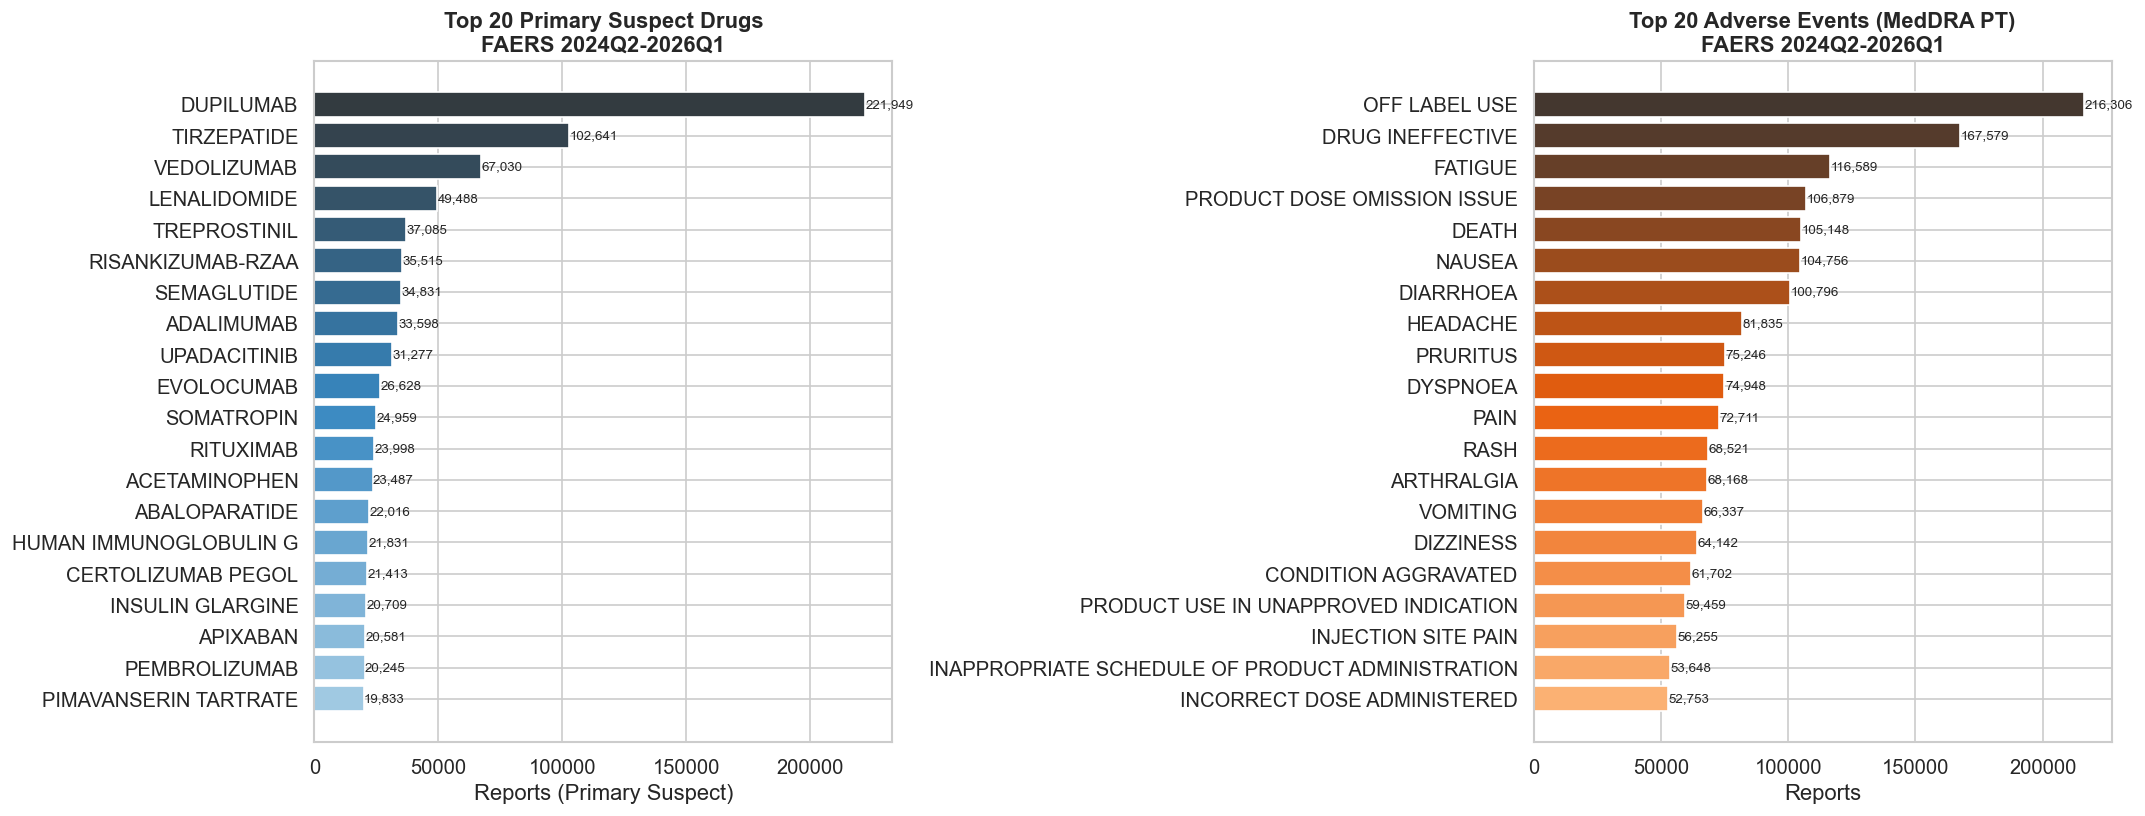

In [15]:
# ── Top 20 drugs & AEs ───────────────────────────────────────────────────────
top_drugs = drug[drug['ROLE_COD']=='PS']['_drug'].value_counts().head(20)
top_aes   = reac['_pt'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].barh(top_drugs.index[::-1], top_drugs.values[::-1], color=sns.color_palette('Blues_d', 20))
axes[0].set_xlabel('Reports (Primary Suspect)')
axes[0].set_title(f'Top 20 Primary Suspect Drugs\nFAERS {QUARTERS[0]}-{QUARTERS[-1]}', fontweight='bold')
for i, val in enumerate(top_drugs.values[::-1]):
    axes[0].text(val + 200, i, f'{val:,}', va='center', fontsize=8)

axes[1].barh(top_aes.index[::-1], top_aes.values[::-1], color=sns.color_palette('Oranges_d', 20))
axes[1].set_xlabel('Reports')
axes[1].set_title(f'Top 20 Adverse Events (MedDRA PT)\nFAERS {QUARTERS[0]}-{QUARTERS[-1]}', fontweight='bold')
for i, val in enumerate(top_aes.values[::-1]):
    axes[1].text(val + 200, i, f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_top_drugs_aes_master.png')
plt.show()

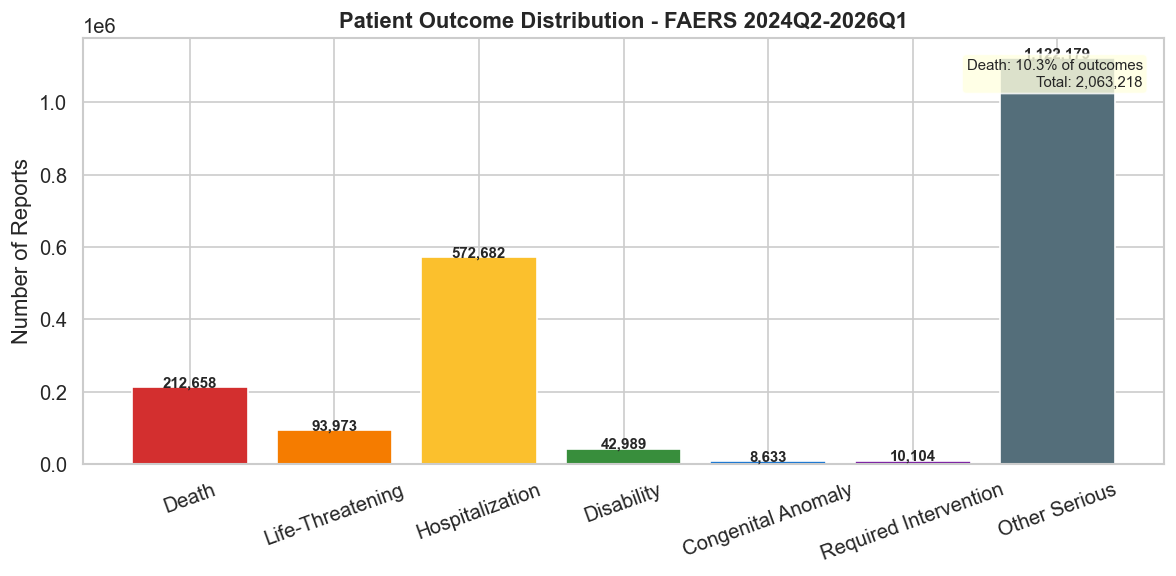

In [16]:
# ── Outcome distribution ─────────────────────────────────────────────────────
outcome_labels = {'DE':'Death','LT':'Life-Threatening','HO':'Hospitalization',
                  'DS':'Disability','CA':'Congenital Anomaly',
                  'RI':'Required Intervention','OT':'Other Serious'}
outc_counts = (outc['OUTC_COD'].map(outcome_labels)
               .value_counts().reindex(outcome_labels.values()).dropna())
colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2','#7b1fa2','#546e7a']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(outc_counts.index, outc_counts.values, color=colors, edgecolor='white')
ax.set_ylabel('Number of Reports')
ax.set_title(f'Patient Outcome Distribution - FAERS {QUARTERS[0]}-{QUARTERS[-1]}', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, outc_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')
death_pct = outc_counts.get('Death',0)/outc_counts.sum()*100
ax.text(0.98, 0.95, f'Death: {death_pct:.1f}% of outcomes\nTotal: {outc_counts.sum():,}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_outcomes_master.png')
plt.show()

In [17]:
# ── Signal detection on full master dataset ──────────────────────────────────
DRUG_TARGET = 'DUPILUMAB'
detector = SignalDetector(drug, reac, drug_col='PROD_AI')
signals  = detector.run_all(DRUG_TARGET, min_reports=10, signal_any=False)
print(f'{DRUG_TARGET}: {len(signals)} AEs with >=10 reports')
print(f'All-3-method signals: {(signals["SIGNAL_COUNT"]==3).sum()}')
signals.head()

DUPILUMAB: 1486 AEs with >=10 reports
All-3-method signals: 187


,PT,a,N,ROR,ROR_CI_lo,ROR_CI_hi,ROR_signal,PRR,PRR_chi2,PRR_p,PRR_signal,EBGM,EB05,EB95,IC,EBGM_signal,SIGNAL_COUNT
0,ENTEROBIASIS,20,2833513,9.108990,5.084990,16.317380,True,9.108255,81.596627,1.668987e-19,True,5.021617,3.491852,7.221565,2.328152,True,3
1,DRAINAGE,49,2833513,4.835817,3.468550,6.742047,True,4.834966,105.839087,7.997249e-25,True,3.623389,2.867956,4.577806,1.857340,True,3
2,DRY EYE,6070,2833513,13.392130,12.909029,13.893310,True,13.051252,32262.494233,0.000000e+00,True,6.729417,6.588827,6.873007,2.750481,True,3
3,EOSINOPHIL COUNT INCREASED,313,2833513,3.876755,3.412008,4.404804,True,3.872674,502.815930,2.318912e-111,True,3.153796,2.873987,3.460848,1.657089,True,3
4,EOSINOPHILIC OESOPHAGITIS,1437,2833513,91.092715,78.241815,106.054323,True,90.506022,14724.393735,0.000000e+00,True,11.314406,10.834002,11.816112,3.500089,True,3


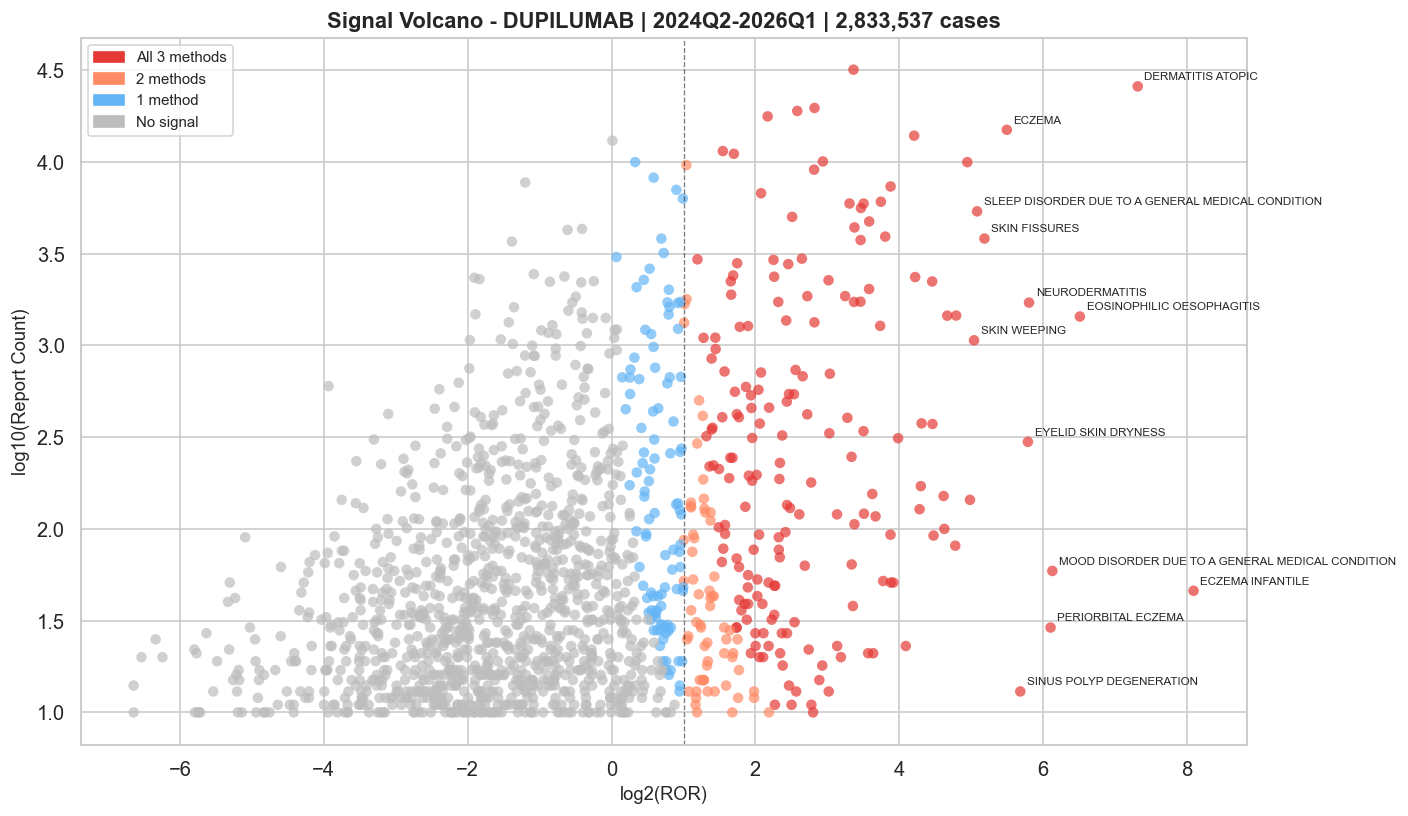

In [18]:
# ── Volcano plot ─────────────────────────────────────────────────────────────
plot_df = signals[(signals['ROR']>0)&(signals['ROR']<500)].copy()
plot_df['log2_ROR'] = np.log2(plot_df['ROR'].clip(0.01))
plot_df['log10_n']  = np.log10(plot_df['a'].clip(1))
cmap = {0:'#bdbdbd',1:'#64b5f6',2:'#ff8a65',3:'#e53935'}
fig, ax = plt.subplots(figsize=(12,7))
ax.scatter(plot_df['log2_ROR'], plot_df['log10_n'],
           c=plot_df['SIGNAL_COUNT'].map(cmap), alpha=0.7, s=40, linewidths=0)
top = plot_df[plot_df['SIGNAL_COUNT']==3].nlargest(12,'ROR')
for _, row in top.iterrows():
    ax.annotate(row['PT'], (row['log2_ROR'], row['log10_n']),
                fontsize=7, xytext=(4,4), textcoords='offset points')
ax.axvline(1, color='black', linestyle='--', lw=0.8, alpha=0.5)
ax.set_xlabel('log2(ROR)', fontsize=11)
ax.set_ylabel('log10(Report Count)', fontsize=11)
ax.set_title(f'Signal Volcano - {DRUG_TARGET} | {QUARTERS[0]}-{QUARTERS[-1]} | {len(demo):,} cases', fontweight='bold')
legend_patches = [mpatches.Patch(color=c, label=l) for c,l in zip(
    ['#e53935','#ff8a65','#64b5f6','#bdbdbd'],
    ['All 3 methods','2 methods','1 method','No signal'])]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f'03_volcano_{DRUG_TARGET}_master.png')
plt.show()

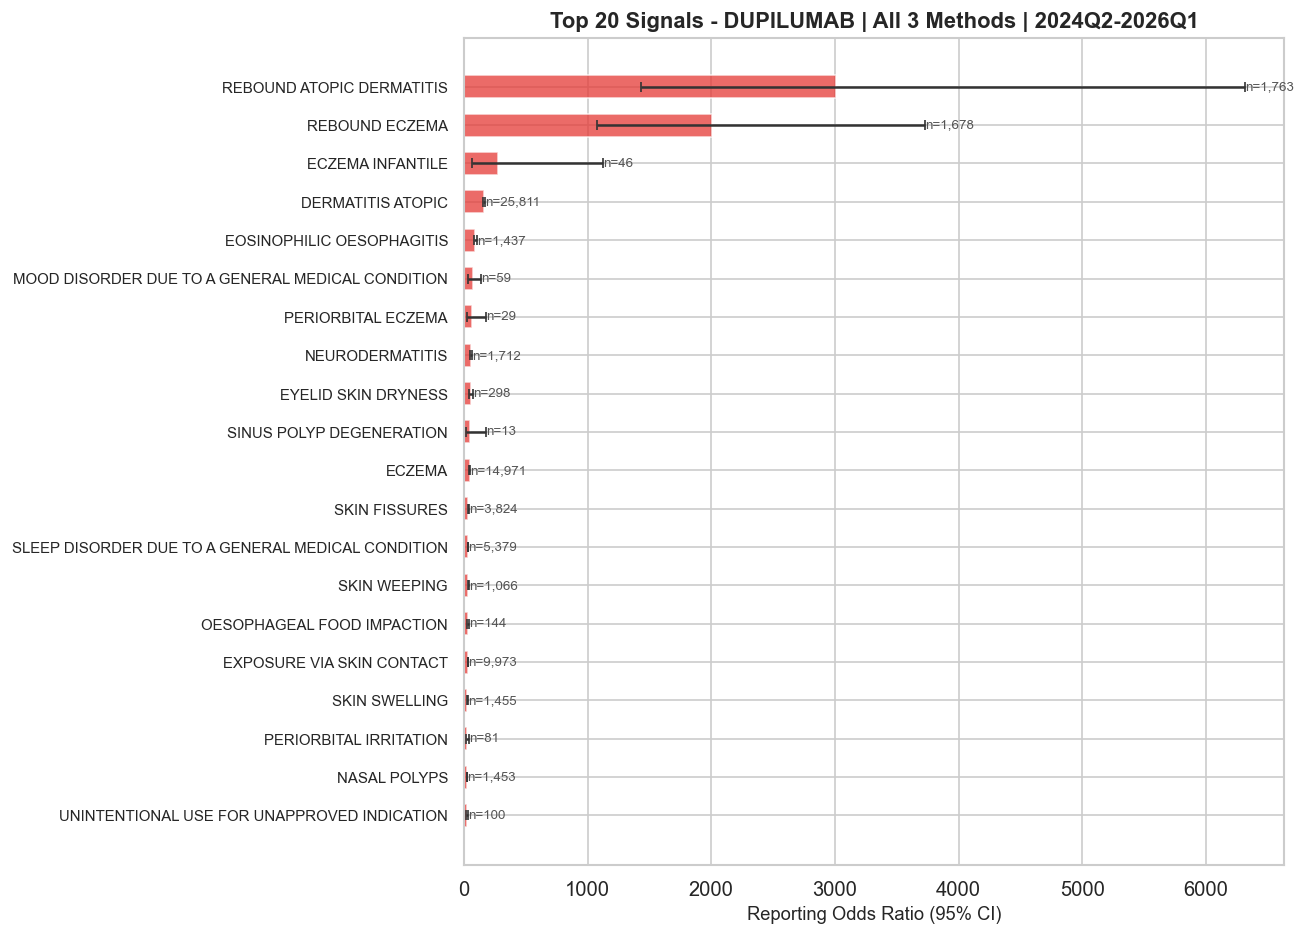

In [19]:
# ── Forest plot ───────────────────────────────────────────────────────────────
forest_df = signals[signals['SIGNAL_COUNT']==3].nlargest(20,'ROR').sort_values('ROR')
fig, ax = plt.subplots(figsize=(11,8))
y = range(len(forest_df))
ax.barh(list(y), forest_df['ROR'],
        xerr=[forest_df['ROR']-forest_df['ROR_CI_lo'], forest_df['ROR_CI_hi']-forest_df['ROR']],
        color='#e53935', alpha=0.75, ecolor='#333', capsize=3, height=0.6)
ax.set_yticks(list(y))
ax.set_yticklabels(forest_df['PT'], fontsize=9)
ax.axvline(1, color='black', linestyle='--', lw=1)
ax.set_xlabel('Reporting Odds Ratio (95% CI)', fontsize=11)
ax.set_title(f'Top 20 Signals - {DRUG_TARGET} | All 3 Methods | {QUARTERS[0]}-{QUARTERS[-1]}', fontweight='bold')
for i, (_, row) in enumerate(forest_df.iterrows()):
    ax.text(row['ROR_CI_hi']+1, i, f"n={int(row['a']):,}", va='center', fontsize=8, color='#555')
plt.tight_layout()
plt.savefig(FIGURES_DIR / f'04_forest_{DRUG_TARGET}_master.png')
plt.show()

---
## Section 2 — Quarter-over-Quarter Trends

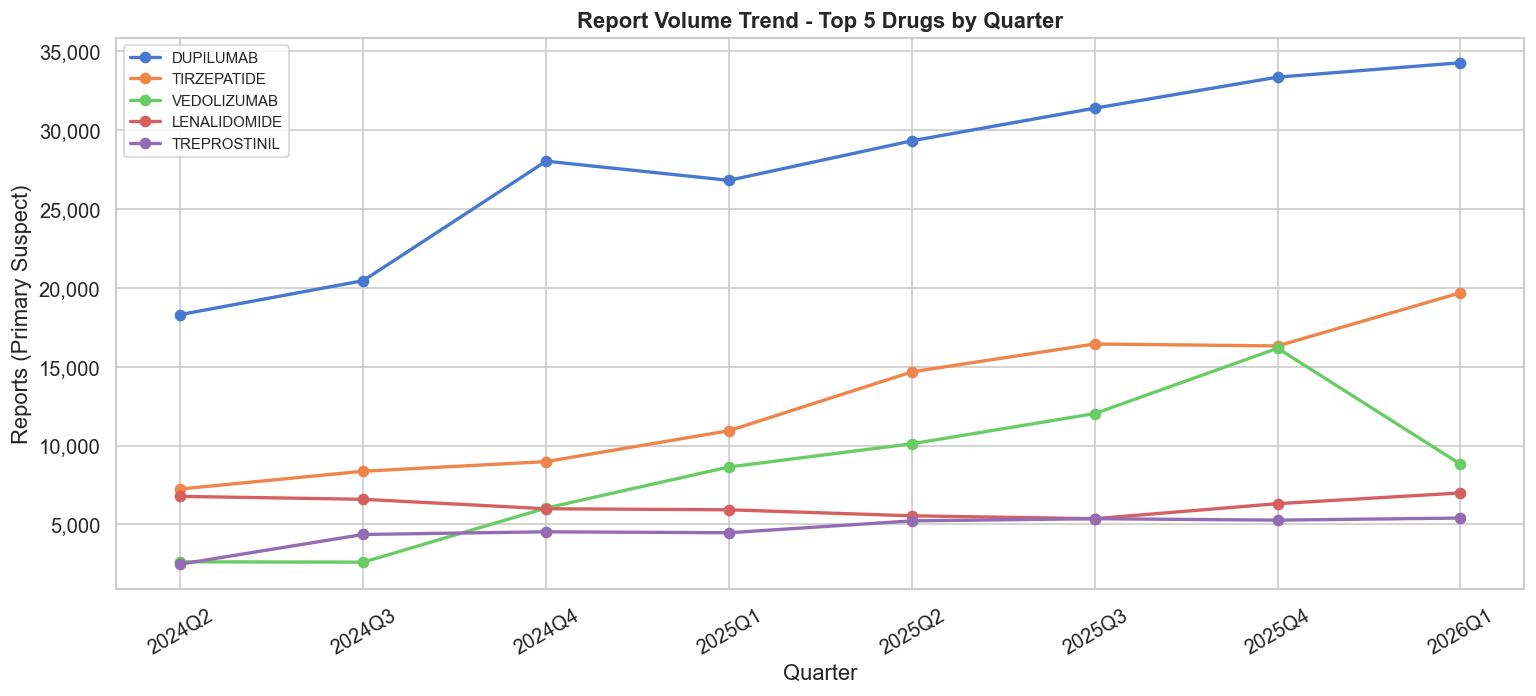

In [20]:
# ── Report volume per quarter per drug ───────────────────────────────────────
# Uses QUARTER column already on drug df (set in cell 1 from demo lookup)
TREND_DRUGS = ['DUPILUMAB','TIRZEPATIDE','VEDOLIZUMAB','LENALIDOMIDE','TREPROSTINIL']

ps = drug[(drug['ROLE_COD']=='PS') & (drug['_drug'].isin(TREND_DRUGS))].copy()

vol = (ps.groupby(['QUARTER','_drug'])
         .size()
         .reset_index(name='reports')
         .pivot(index='QUARTER', columns='_drug', values='reports')
         .fillna(0))

fig, ax = plt.subplots(figsize=(13,6))
for d in TREND_DRUGS:
    if d in vol.columns:
        ax.plot(vol.index, vol[d], marker='o', linewidth=2, label=d)
ax.set_xlabel('Quarter')
ax.set_ylabel('Reports (Primary Suspect)')
ax.set_title('Report Volume Trend - Top 5 Drugs by Quarter', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_report_volume_trend.png')
plt.show()

In [21]:
# ── ROR trend per quarter for DUPILUMAB top signals ──────────────────────────
TOP_AES_TO_TRACK = (signals[signals['SIGNAL_COUNT']==3].nlargest(6,'a')['PT'].tolist())
print(f'Tracking: {TOP_AES_TO_TRACK}')

ror_by_quarter = {ae: [] for ae in TOP_AES_TO_TRACK}

for q in QUARTERS:
    q_pids   = set(demo[demo['QUARTER']==q]['PRIMARYID'])
    q_drug   = drug[drug['PRIMARYID'].isin(q_pids)]
    q_reac   = reac[reac['PRIMARYID'].isin(q_pids)]
    if len(q_drug) == 0:
        continue
    try:
        det_q  = SignalDetector(q_drug, q_reac, drug_col='PROD_AI')
        sigs_q = det_q.run_all(DRUG_TARGET, min_reports=3, signal_any=False)
        for ae in TOP_AES_TO_TRACK:
            row = sigs_q[sigs_q['PT']==ae]
            if len(row) > 0:
                ror_by_quarter[ae].append((q, float(row.iloc[0]['ROR']),
                                           float(row.iloc[0]['ROR_CI_lo']),
                                           float(row.iloc[0]['ROR_CI_hi'])))
            else:
                ror_by_quarter[ae].append((q, np.nan, np.nan, np.nan))
    except Exception as e:
        print(f'  {q}: {e}')
print('Done.')

Tracking: ['PRURITUS', 'DERMATITIS ATOPIC', 'INJECTION SITE PAIN', 'PRODUCT USE IN UNAPPROVED INDICATION', 'RASH', 'ECZEMA']
Done.


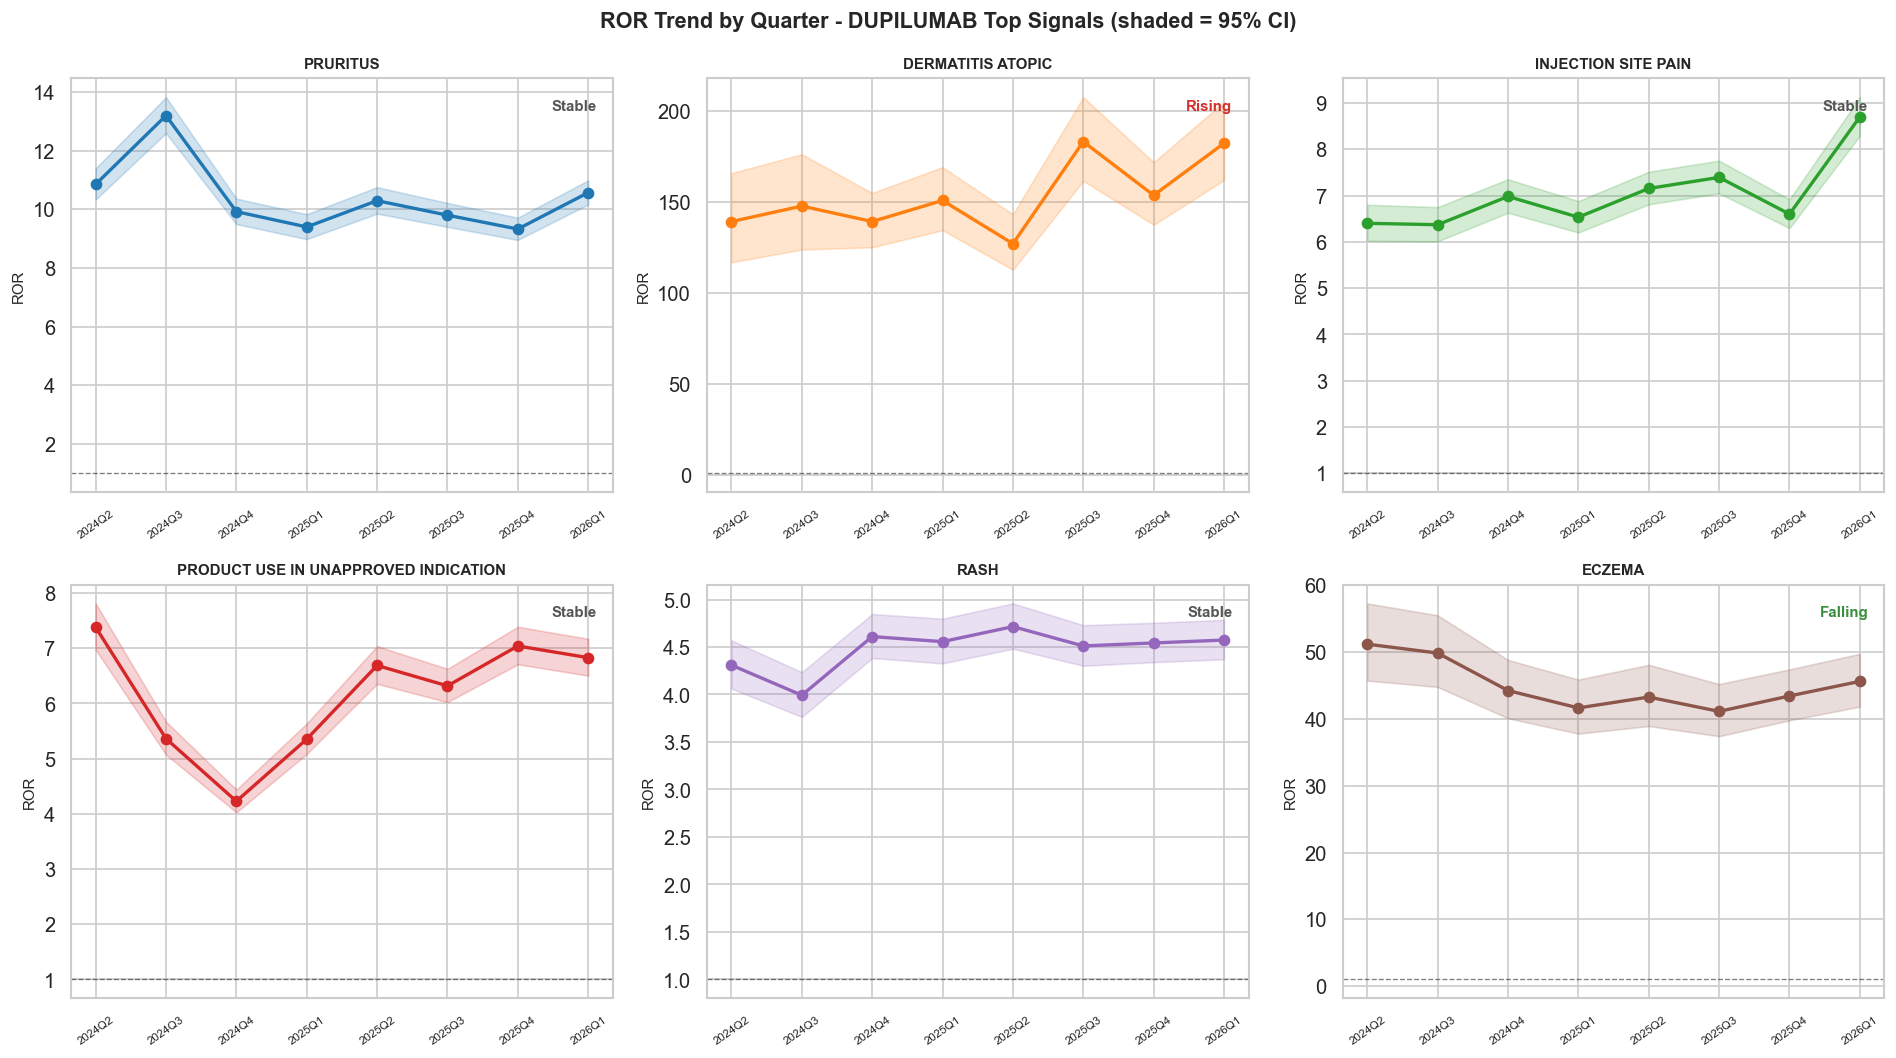

In [22]:
# ── Plot ROR trends with confidence bands ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()
colors_trend = sns.color_palette('tab10', 6)

for idx, (ae, data) in enumerate(ror_by_quarter.items()):
    if idx >= 6 or not data:
        continue
    ax = axes[idx]
    df_t = pd.DataFrame(data, columns=['quarter','ROR','CI_lo','CI_hi']).dropna()
    if len(df_t) < 2:
        ax.set_title(ae[:35], fontsize=9)
        ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes, ha='center')
        continue
    x = range(len(df_t))
    ax.plot(x, df_t['ROR'], color=colors_trend[idx], marker='o', linewidth=2)
    ax.fill_between(x, df_t['CI_lo'], df_t['CI_hi'], color=colors_trend[idx], alpha=0.2)
    ax.axhline(1, color='black', linestyle='--', lw=0.8, alpha=0.5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_t['quarter'], rotation=35, fontsize=7)
    ax.set_ylabel('ROR', fontsize=9)
    ax.set_title(ae[:40], fontsize=9, fontweight='bold')
    if len(df_t) >= 3:
        slope = np.polyfit(range(len(df_t)), df_t['ROR'], 1)[0]
        direction = 'Rising' if slope > 0.5 else ('Falling' if slope < -0.5 else 'Stable')
        color_ann = '#d32f2f' if slope > 0.5 else ('#388e3c' if slope < -0.5 else '#555')
        ax.text(0.97, 0.95, direction, transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color=color_ann, fontweight='bold')

fig.suptitle(f'ROR Trend by Quarter - {DRUG_TARGET} Top Signals (shaded = 95% CI)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / f'06_ror_trends_{DRUG_TARGET}.png')
plt.show()

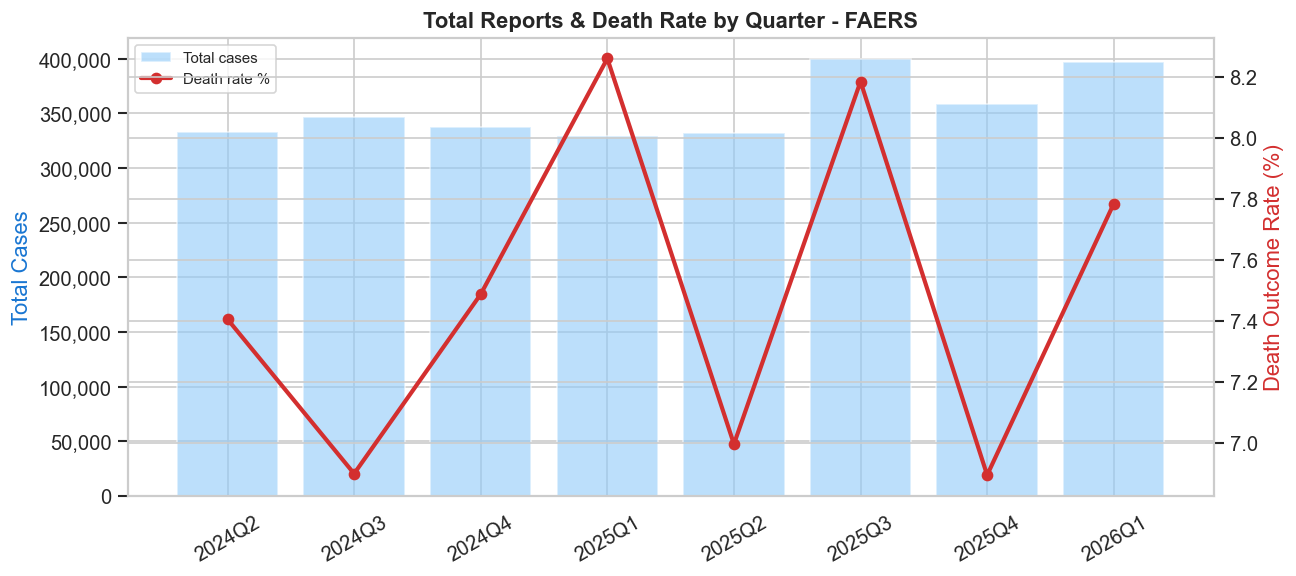

In [23]:
# ── Death rate trend by quarter ───────────────────────────────────────────────
quarterly_deaths = []
for q in QUARTERS:
    q_pids  = set(demo[demo['QUARTER']==q]['PRIMARYID'])
    total   = len(q_pids)
    deaths  = outc[outc['PRIMARYID'].isin(q_pids) & (outc['OUTC_COD']=='DE')]['PRIMARYID'].nunique()
    quarterly_deaths.append({'quarter':q,'total':total,'deaths':deaths,
                              'death_rate':deaths/total*100 if total>0 else 0})
dq = pd.DataFrame(quarterly_deaths)

fig, ax1 = plt.subplots(figsize=(11,5))
ax2 = ax1.twinx()
x = range(len(dq))
ax1.bar(x, dq['total'], color='#90caf9', alpha=0.6, label='Total cases')
ax2.plot(x, dq['death_rate'], color='#d32f2f', marker='o', linewidth=2.5, label='Death rate %')
ax1.set_xticks(list(x))
ax1.set_xticklabels(dq['quarter'], rotation=30)
ax1.set_ylabel('Total Cases', color='#1976d2')
ax2.set_ylabel('Death Outcome Rate (%)', color='#d32f2f')
ax1.set_title('Total Reports & Death Rate by Quarter - FAERS', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_death_rate_trend.png')
plt.show()

Emerging signals (['2025Q4', '2026Q1'], absent in earlier quarters): 38


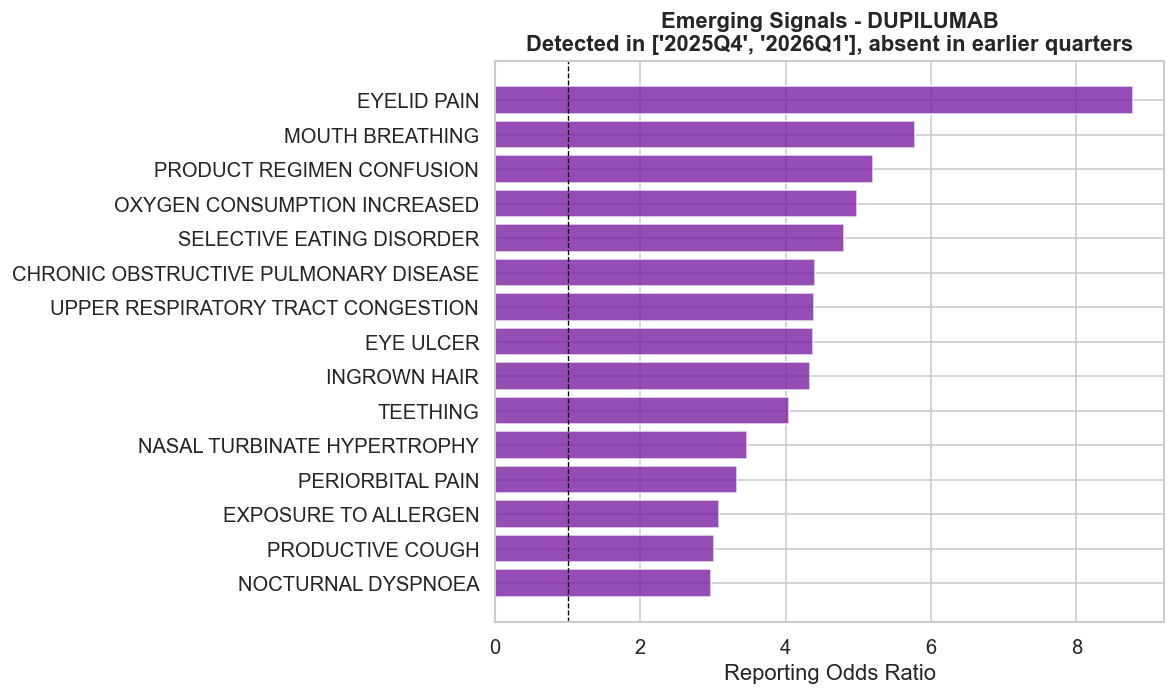

                                   PT   a      ROR  SIGNAL_COUNT
                          EYELID PAIN  27 8.772550             3
                      MOUTH BREATHING   5 5.774442             2
            PRODUCT REGIMEN CONFUSION   6 5.197053             2
         OXYGEN CONSUMPTION INCREASED  35 4.985214             3
            SELECTIVE EATING DISORDER   6 4.797273             2
CHRONIC OBSTRUCTIVE PULMONARY DISEASE 583 4.401694             3
   UPPER RESPIRATORY TRACT CONGESTION  19 4.389273             3
                            EYE ULCER   8 4.376553             2
                         INGROWN HAIR   5 4.330812             2
                             TEETHING   7 4.042178             2
          NASAL TURBINATE HYPERTROPHY   5 3.464635             2
                     PERIORBITAL PAIN   8 3.326152             2
                 EXPOSURE TO ALLERGEN   8 3.079761             2
                     PRODUCTIVE COUGH 635 3.015098             3
                   NOCTUR

In [24]:
# ── Emerging signals — new in last 2 quarters ────────────────────────────────
recent_qs  = QUARTERS[-2:]
earlier_qs = QUARTERS[:-2]

def get_signals_for_quarters(qs, drug_name, min_reports=5):
    q_pids  = set(demo[demo['QUARTER'].isin(qs)]['PRIMARYID'])
    q_drug  = drug[drug['PRIMARYID'].isin(q_pids)]
    q_reac  = reac[reac['PRIMARYID'].isin(q_pids)]
    if len(q_drug) == 0:
        return pd.DataFrame()
    det = SignalDetector(q_drug, q_reac, drug_col='PROD_AI')
    return det.run_all(drug_name, min_reports=min_reports, signal_any=True)

recent_sigs  = get_signals_for_quarters(recent_qs,  DRUG_TARGET)
earlier_sigs = get_signals_for_quarters(earlier_qs, DRUG_TARGET)

if len(recent_sigs) > 0 and len(earlier_sigs) > 0:
    earlier_pts = set(earlier_sigs[earlier_sigs['SIGNAL_COUNT']>=2]['PT'])
    emerging    = recent_sigs[
        (recent_sigs['SIGNAL_COUNT']>=2) & (~recent_sigs['PT'].isin(earlier_pts))
    ].sort_values('ROR', ascending=False)
    print(f'Emerging signals ({recent_qs}, absent in earlier quarters): {len(emerging)}')
    if len(emerging) >= 3:
        plot_em = emerging.head(15).sort_values('ROR')
        fig, ax = plt.subplots(figsize=(10,6))
        ax.barh(plot_em['PT'], plot_em['ROR'], color='#7b1fa2', alpha=0.8)
        ax.axvline(1, color='black', linestyle='--', lw=0.8)
        ax.set_xlabel('Reporting Odds Ratio')
        ax.set_title(f'Emerging Signals - {DRUG_TARGET}\nDetected in {recent_qs}, absent in earlier quarters',
                     fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'08_emerging_signals_{DRUG_TARGET}.png')
        plt.show()
    print(emerging[['PT','a','ROR','SIGNAL_COUNT']].head(15).to_string(index=False))

In [25]:
print('=== Complete ===')
print(f'Dataset: {len(demo):,} cases | {QUARTERS[0]}-{QUARTERS[-1]}')
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f'  {f.name}')

=== Complete ===
Dataset: 2,833,537 cases | 2024Q2-2026Q1
  01_top_drugs_aes.png
  01_top_drugs_aes_master.png
  02_outcome_distribution.png
  02_outcomes_master.png
  03_volcano_DUPILUMAB.png
  03_volcano_DUPILUMAB_master.png
  04_forest_DUPILUMAB.png
  04_forest_DUPILUMAB_master.png
  05_death_rate_by_drug.png
  05_report_volume_trend.png
  06_demographics.png
  06_ror_trends_DUPILUMAB.png
  07_death_rate_trend.png
  08_emerging_signals_DUPILUMAB.png
